# Experiments

Tasks are defined as 2D manipulation problems that vary along two dimensions:

- **Distance**: how far the object must be moved from start to goal (short / medium / long)
- **Orientation change**: how much the object must be rotated (none / 45° / 90°)

This gives a 3 × 3 grid of conditions. Each condition is run across four developmental
stages (A = youngest, D = most mature) and across all affordance matrix variants.

## Key Outputs

- **Success rate** — proportion of trials where the agent reached the goal within tolerance
- **Path efficiency** — optimal/actual path length (1 = perfectly direct)
- **Mean timesteps** — trial duration (lower = faster)
- **Gaze switches** — fixation shifts between object and target
- **Movement onset** — steps before the agent starts moving (deliberation time)
- **Example trajectories** — 2D path shapes for qualitative comparison

In [1]:
from dataclasses import replace
from html import escape
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import math

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = lambda content: content
    display = print

# Support running from either the repository root or the gaze_model folder.
cwd = Path.cwd()
if (cwd / "planning_cascade_model.py").exists():
    sys.path.insert(0, str(cwd))
elif (cwd / "gaze_model" / "planning_cascade_model.py").exists():
    sys.path.insert(0, str(cwd / "gaze_model"))

from affordance_matrices import AFFORDANCE_MATRIX_VARIANTS
from model_utils import DevelopmentalParams, TaskConfig
from planning_cascade_model import run_trial
from model_utils import run_simulation, group_results, summarise_group

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## Developmental Stage Profiles

Four profiles to try to capture the major perceptual, attentional, and motor changes across early development. A = youngest, D = most mature

In [2]:
DEVELOPMENTAL_STAGES = {
    "A": DevelopmentalParams(
        name="A",
        gaze_switch_rate=0.12, fixation_duration_mean=5.0, target_bias=0.20,
        simultaneous_rate=0.03, sampling_rate=0.30, perceptual_noise=0.35,
        location_acuity=0.70, orientation_acuity=0.15, relation_acuity=0.05,
        wm_capacity=2, wm_decay=0.18, wm_unfixated_decay=0.40,
        affordance_coupling=0.25, affordance_noise=0.25, planning_horizon=1,
        motor_noise=0.20, habit_strength=0.78, goal_directed_strength=0.22,
        correction_rate=0.12, correction_delay=2, initiation_threshold=0.15,
    ),
    "B": DevelopmentalParams(
        name="B",
        gaze_switch_rate=0.25, fixation_duration_mean=3.5, target_bias=0.35,
        simultaneous_rate=0.12, sampling_rate=0.45, perceptual_noise=0.28,
        location_acuity=0.85, orientation_acuity=0.30, relation_acuity=0.12,
        wm_capacity=3, wm_decay=0.12, wm_unfixated_decay=0.28,
        affordance_coupling=0.40, affordance_noise=0.22, planning_horizon=2,
        motor_noise=0.22, habit_strength=0.70, goal_directed_strength=0.30,
        correction_rate=0.14, correction_delay=2, initiation_threshold=0.28,
    ),
    "C": DevelopmentalParams(
        name="C",
        gaze_switch_rate=0.40, fixation_duration_mean=2.5, target_bias=0.50,
        simultaneous_rate=0.28, sampling_rate=0.65, perceptual_noise=0.16,
        location_acuity=0.93, orientation_acuity=0.55, relation_acuity=0.30,
        wm_capacity=4, wm_decay=0.08, wm_unfixated_decay=0.18,
        affordance_coupling=0.60, affordance_noise=0.14, planning_horizon=4,
        motor_noise=0.16, habit_strength=0.40, goal_directed_strength=0.60,
        correction_rate=0.22, correction_delay=1, initiation_threshold=0.40,
    ),
    "D": DevelopmentalParams(
        name="D",
        gaze_switch_rate=0.55, fixation_duration_mean=2.0, target_bias=0.60,
        simultaneous_rate=0.50, sampling_rate=0.85, perceptual_noise=0.08,
        location_acuity=0.98, orientation_acuity=0.88, relation_acuity=0.55,
        wm_capacity=5, wm_decay=0.04, wm_unfixated_decay=0.10,
        affordance_coupling=0.85, affordance_noise=0.08, planning_horizon=6,
        motor_noise=0.08, habit_strength=0.10, goal_directed_strength=0.90,
        correction_rate=0.28, correction_delay=0, initiation_threshold=0.45,
    ),
}

STAGE_COLOURS = {"A": "#0584CD", "B": "#E76C1F", "C": "#7C0DC2", "D": "#6A6A6A"}

## Task Configs, Orientation × Distance

Object starts at (0, 0) facing 0 rad.
The goal varies in **distance** (how far to move) and **orientation change** (how much
to rotate).

| Distance | Label | Goal x |
|----------|-------|--------|
| Short    | 0.3 units | 0.3 |
| Medium   | 0.5 units | 0.5 |
| Long     | 0.8 units | 0.8 |


| Orientation change | Label | Goal angle |
|--------------------|-------|------------|
| None               | aligned | 0 rad |
| 45°                | small_rot | π/4 ≈ 0.785 rad |
| 90°                | large_rot | π/2 ≈ 1.571 rad |

To add a new condition, define another `TaskConfig` and add it to `TASKS`.

In [3]:
# Common object dimensions for all tasks
_W, _H = 0.3, 0.5

TASKS = {
    # Short distance (0.3 units)
    "short_aligned": TaskConfig(
        name="short_aligned",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.3, goal_y=0.0, goal_angle=0.0,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    "short_small_rot": TaskConfig(
        name="short_small_rot",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.3, goal_y=0.0, goal_angle=math.pi / 4,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    "short_large_rot": TaskConfig(
        name="short_large_rot",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.3, goal_y=0.0, goal_angle=math.pi / 2,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    # Medium distance (0.5 units)
    "medium_aligned": TaskConfig(
        name="medium_aligned",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.5, goal_y=0.0, goal_angle=0.0,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    "medium_small_rot": TaskConfig(
        name="medium_small_rot",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.5, goal_y=0.0, goal_angle=math.pi / 4,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    "medium_large_rot": TaskConfig(
        name="medium_large_rot",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.5, goal_y=0.0, goal_angle=math.pi / 2,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    # Long distance (0.8 units)
    "long_aligned": TaskConfig(
        name="long_aligned",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.8, goal_y=0.0, goal_angle=0.0,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    "long_small_rot": TaskConfig(
        name="long_small_rot",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.8, goal_y=0.0, goal_angle=math.pi / 4,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
    "long_large_rot": TaskConfig(
        name="long_large_rot",
        start_x=0.0, start_y=0.0, start_angle=0.0,
        goal_x=0.8, goal_y=0.0, goal_angle=math.pi / 2,
        obj_width=_W, obj_height=_H, max_timesteps=120,
    ),
}

# Params for grouping plots by distance / rotation
DISTANCE_LABELS = ["short", "medium", "long"]
ROTATION_LABELS = ["aligned", "small_rot", "large_rot"]
ROTATION_DISPLAY = {"aligned": "0°", "small_rot": "45°", "large_rot": "90°"}
TASK_COLOURS = {
    "short_aligned": "#2196F3", "short_small_rot": "#64B5F6", "short_large_rot": "#BBDEFB",
    "medium_aligned": "#E76C1F", "medium_small_rot": "#FFB74D", "medium_large_rot": "#FFE0B2",
    "long_aligned": "#7C0DC2", "long_small_rot": "#BA68C8", "long_large_rot": "#E1BEE7",
}

N_TRIALS = 25
SEED = 42
print(f"{len(TASKS)} tasks × {len(DEVELOPMENTAL_STAGES)} stages × {N_TRIALS} trials = {len(TASKS) * len(DEVELOPMENTAL_STAGES) * N_TRIALS} total runs")

9 tasks × 4 stages × 25 trials = 900 total runs


## Run Simulations

Loops over every (stage, task, trial) combination and returns
a flat list of `TrialResult` objects.

In [4]:
results = run_simulation(DEVELOPMENTAL_STAGES, TASKS, n_trials=N_TRIALS, seed=SEED)
groups = group_results(results)
summary = [
    summarise_group(stage, task, trials)
    for (stage, task), trials in groups.items()
]
print(f"Finished. {len(results)} trial results across {len(groups)} (stage, task) groups.")

Finished. 900 trial results across 36 (stage, task) groups.


## Results Table

In [5]:
def format_cell(value):
    if isinstance(value, float):
        return f"{value:.3f}"
    return escape(str(value))

def rows_to_html(rows, columns):
    header = "".join(f"<th>{escape(c)}</th>" for c in columns)
    body = "".join(
        f"<tr>{''.join(f'<td>{format_cell(row[c])}</td>' for c in columns)}</tr>"
        for row in rows
    )
    style = "border-collapse:collapse;font-family:sans-serif;font-size:12px;"
    cell_style = "th,td{border:1px solid #ddd;padding:3px 7px;text-align:right}th:first-child,td:first-child,th:nth-child(2),td:nth-child(2){text-align:left}"
    return f"<style>{cell_style}</style><table style='{style}'><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"

# Sort by stage then task name
sorted_summary = sorted(summary, key=lambda r: (r["stage"], r["task"]))
columns = ["stage", "task", "n_trials", "success_rate", "mean_timesteps",
           "mean_pos_error", "mean_angle_error", "mean_efficiency",
           "mean_movement_onset", "mean_gaze_switches"]
display(HTML(rows_to_html(sorted_summary, columns)))

stage,task,n_trials,success_rate,mean_timesteps,mean_pos_error,mean_angle_error,mean_efficiency,mean_movement_onset,mean_gaze_switches
A,long_aligned,25,0.440,93.520,1.568,0.598,0.337,3.840,8.000
A,long_large_rot,25,0.000,120.000,2.782,1.245,0.252,3.840,10.160
A,long_small_rot,25,0.240,108.920,2.100,0.869,0.290,3.840,9.200
A,medium_aligned,25,1.000,45.760,0.048,0.022,0.902,3.840,3.880
A,medium_large_rot,25,0.000,120.000,2.733,1.239,0.241,3.840,10.160
A,medium_small_rot,25,0.280,105.640,1.961,0.820,0.294,3.840,8.920
A,short_aligned,25,1.000,39.760,0.048,0.014,1.000,3.840,3.240
A,short_large_rot,25,0.000,120.000,2.700,1.235,0.237,3.840,10.160
A,short_small_rot,25,0.240,106.960,2.043,0.865,0.261,3.840,8.960
B,long_aligned,25,0.760,71.800,0.514,0.202,0.553,7.400,11.480


## Success Rate Heatmap — Distance × Rotation by Stage

Each panel shows one developmental stage. Rows = rotation demand, columns = distance.
Darker cells = higher success rate.

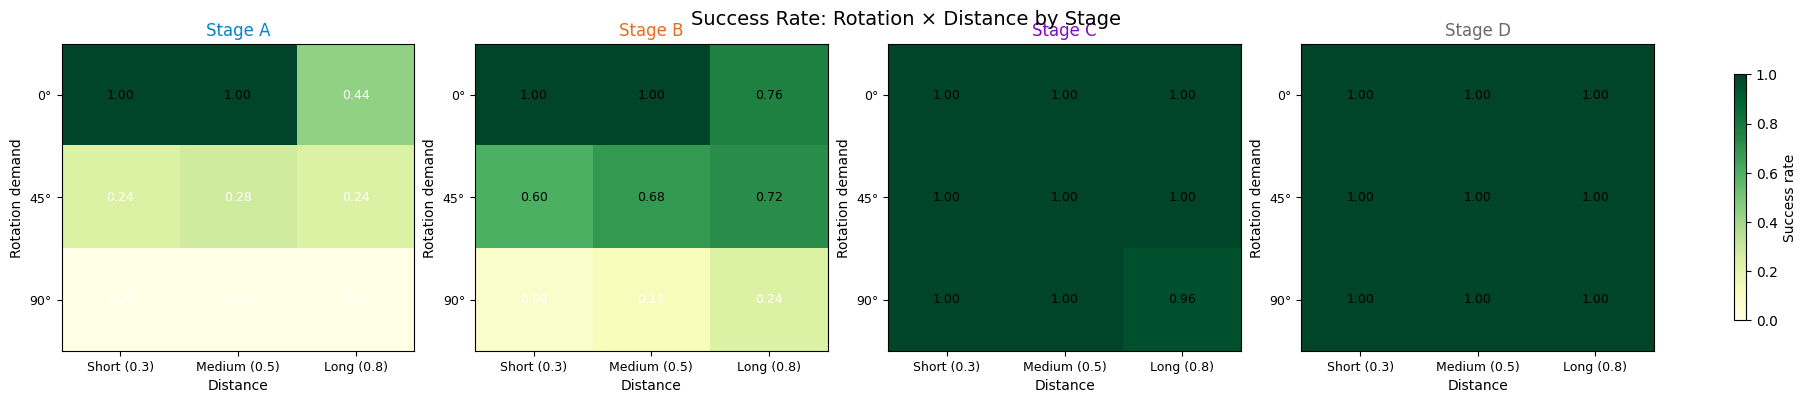

In [6]:
def get_metric(summary, stage, task, metric):
    for row in summary:
        if row["stage"] == stage and row["task"] == task:
            return row[metric]
    return float("nan")

stage_names = list(DEVELOPMENTAL_STAGES)
fig, axes = plt.subplots(1, len(stage_names), figsize=(4.5 * len(stage_names), 3.8), constrained_layout=True)

for ax, stage in zip(axes, stage_names):
    matrix = np.array([
        [get_metric(summary, stage, f"{dist}_{rot}", "success_rate")
         for dist in DISTANCE_LABELS]
        for rot in ROTATION_LABELS
    ])
    im = ax.imshow(matrix, vmin=0, vmax=1, cmap="YlGn", aspect="auto")
    ax.set_title(f"Stage {stage}", fontsize=12, color=STAGE_COLOURS[stage])
    ax.set_xticks(range(len(DISTANCE_LABELS)))
    ax.set_xticklabels(["Short (0.3)", "Medium (0.5)", "Long (0.8)"], fontsize=9)
    ax.set_yticks(range(len(ROTATION_LABELS)))
    ax.set_yticklabels([ROTATION_DISPLAY[r] for r in ROTATION_LABELS], fontsize=9)
    ax.set_xlabel("Distance")
    ax.set_ylabel("Rotation demand")
    for r, rot in enumerate(ROTATION_LABELS):
        for c, dist in enumerate(DISTANCE_LABELS):
            v = matrix[r, c]
            ax.text(c, r, f"{v:.2f}", ha="center", va="center",
                    fontsize=9, color="black" if v > 0.5 else "white")

fig.colorbar(im, ax=axes, shrink=0.8, label="Success rate")
fig.suptitle("Success Rate: Rotation × Distance by Stage", fontsize=14, y=1.02)
plt.show()

## Metric Profiles Across Tasks

Bar charts showing success rate, efficiency, and mean timesteps broken down by
stage.

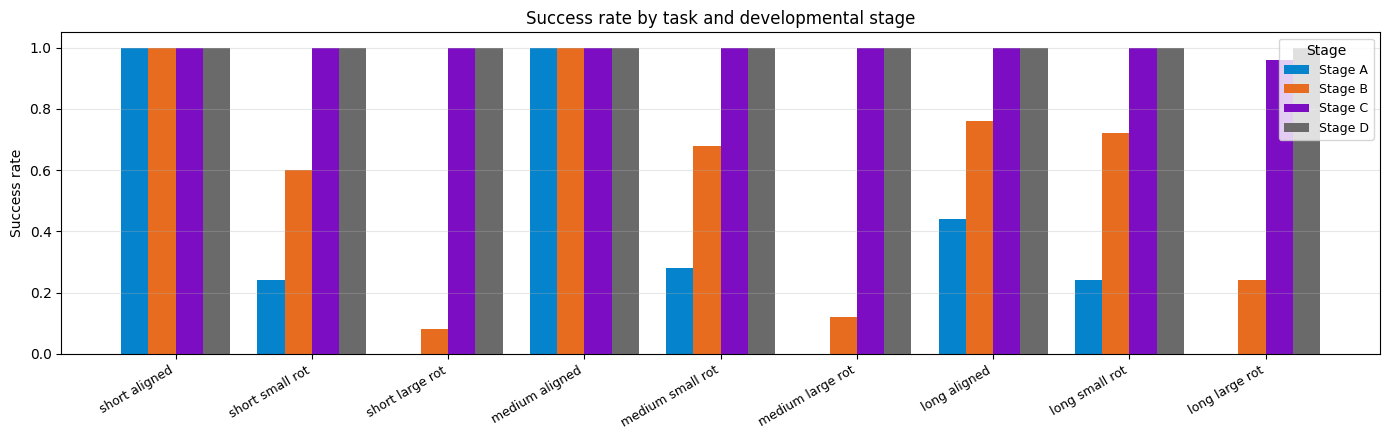

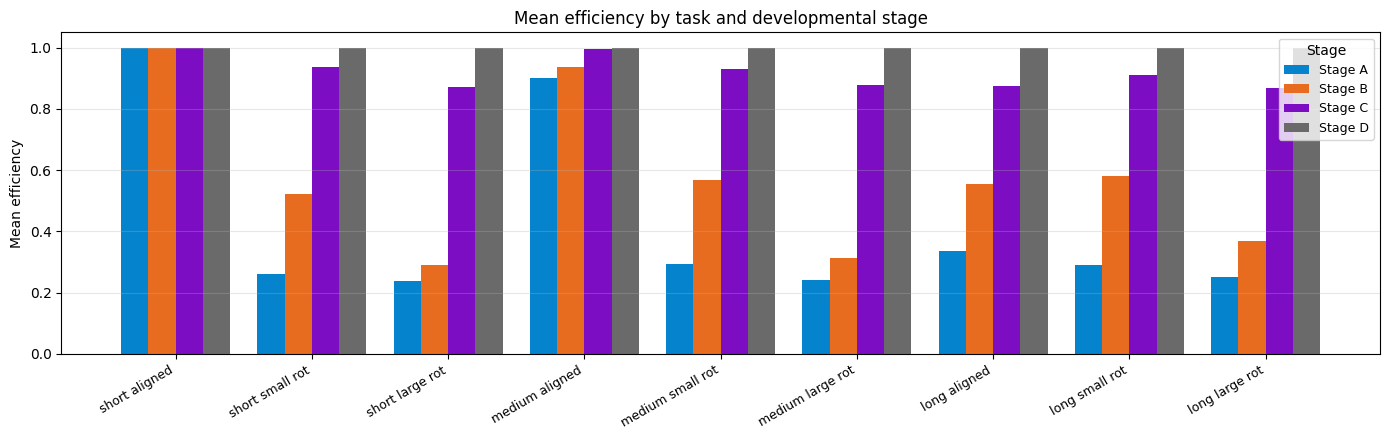

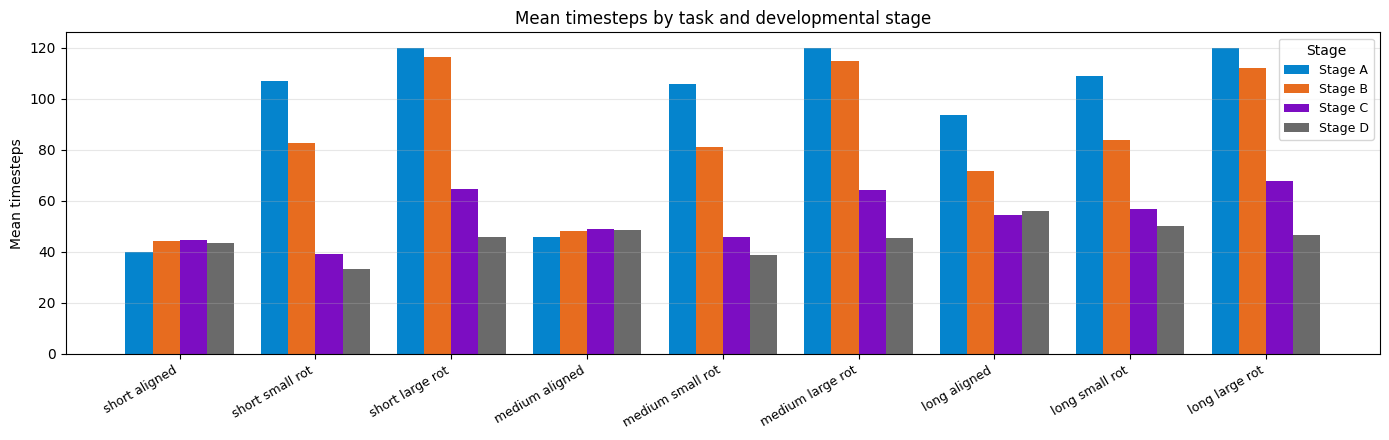

In [7]:
def plot_metric_by_task(summary, metric, ylabel, task_names, stage_names):
    x = np.arange(len(task_names))
    width = 0.8 / len(stage_names)
    fig, ax = plt.subplots(figsize=(14, 4.5))
    for i, stage in enumerate(stage_names):
        values = [get_metric(summary, stage, t, metric) for t in task_names]
        offset = (i - (len(stage_names) - 1) / 2) * width
        ax.bar(x + offset, values, width=width, label=f"Stage {stage}",
               color=STAGE_COLOURS[stage])
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("_", " ") for t in task_names], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by task and developmental stage")
    ax.legend(title="Stage", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

task_names = list(TASKS)
stage_names = list(DEVELOPMENTAL_STAGES)
plot_metric_by_task(summary, "success_rate", "Success rate", task_names, stage_names)
plot_metric_by_task(summary, "mean_efficiency", "Mean efficiency", task_names, stage_names)
plot_metric_by_task(summary, "mean_timesteps", "Mean timesteps", task_names, stage_names)

## Main Effects: Distance and Rotation Demand

Marginal means averaging across the other factor. Left: effect of distance (collapsing
over rotation). Right: effect of rotation demand (collapsing over distance). Lines
show each developmental stage.

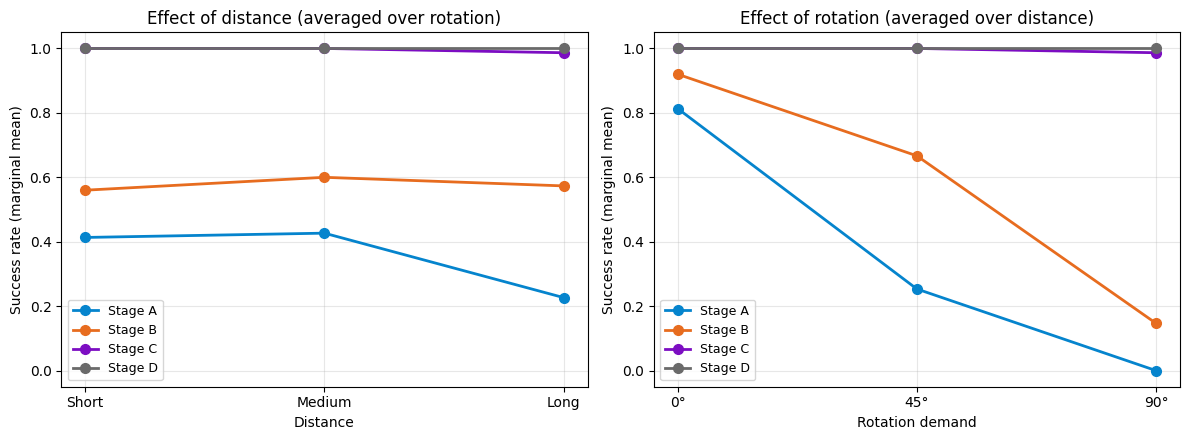

In [8]:
def marginal_mean(summary, stage, fixed_key, fixed_values, other_values, metric):
    """Mean metric across all combinations where the fixed factor takes fixed_values."""
    means = []
    for fv in fixed_values:
        vals = [
            get_metric(summary, stage, f"{fv}_{ov}" if fixed_key == "dist" else f"{ov}_{fv}", metric)
            for ov in other_values
        ]
        means.append(np.nanmean(vals))
    return means

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: distance main effect
ax = axes[0]
for stage in stage_names:
    y = marginal_mean(summary, stage, "dist", DISTANCE_LABELS, ROTATION_LABELS, "success_rate")
    ax.plot(["Short", "Medium", "Long"], y, "o-", color=STAGE_COLOURS[stage], label=f"Stage {stage}", lw=2, markersize=7)
ax.set_xlabel("Distance")
ax.set_ylabel("Success rate (marginal mean)")
ax.set_title("Effect of distance (averaged over rotation)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Right: rotation main effect
ax = axes[1]
rot_display = [ROTATION_DISPLAY[r] for r in ROTATION_LABELS]
for stage in stage_names:
    y = marginal_mean(summary, stage, "rot", ROTATION_LABELS, DISTANCE_LABELS, "success_rate")
    ax.plot(rot_display, y, "o-", color=STAGE_COLOURS[stage], label=f"Stage {stage}", lw=2, markersize=7)
ax.set_xlabel("Rotation demand")
ax.set_ylabel("Success rate (marginal mean)")
ax.set_title("Effect of rotation (averaged over distance)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## Gaze Behaviour Across Conditions

How gaze allocation (object vs. target fixation) and switch rate vary with task
difficulty. Higher target fixation in mature stages reflects stronger anticipatory
goal representation.

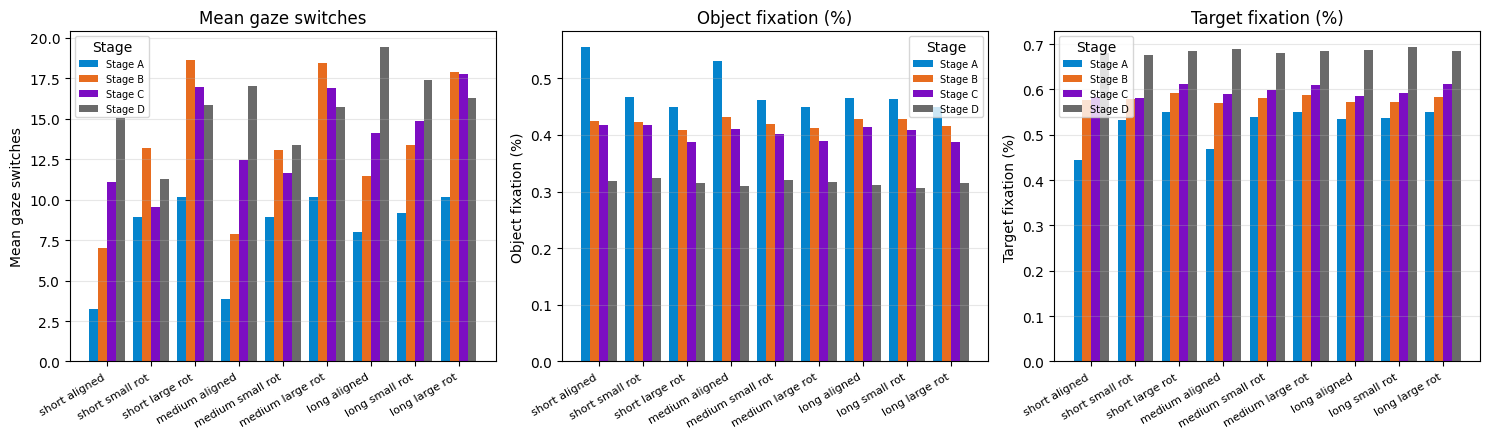

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metrics = [
    ("mean_gaze_switches", "Mean gaze switches"),
    ("mean_object_fixation_pct", "Object fixation (%)"),
    ("mean_target_fixation_pct", "Target fixation (%)"),
]

for ax, (metric, ylabel) in zip(axes, metrics):
    x = np.arange(len(task_names))
    width = 0.8 / len(stage_names)
    for i, stage in enumerate(stage_names):
        values = [get_metric(summary, stage, t, metric) for t in task_names]
        offset = (i - (len(stage_names) - 1) / 2) * width
        ax.bar(x + offset, values, width=width, label=f"Stage {stage}",
               color=STAGE_COLOURS[stage])
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace("_", " ") for t in task_names], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(title="Stage", fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Example Trajectories

2D paths for one representative trial per (stage, task) pair. Choose any task name
from `TASKS` to inspect. Markers show timesteps (denser dots mean slower movement).

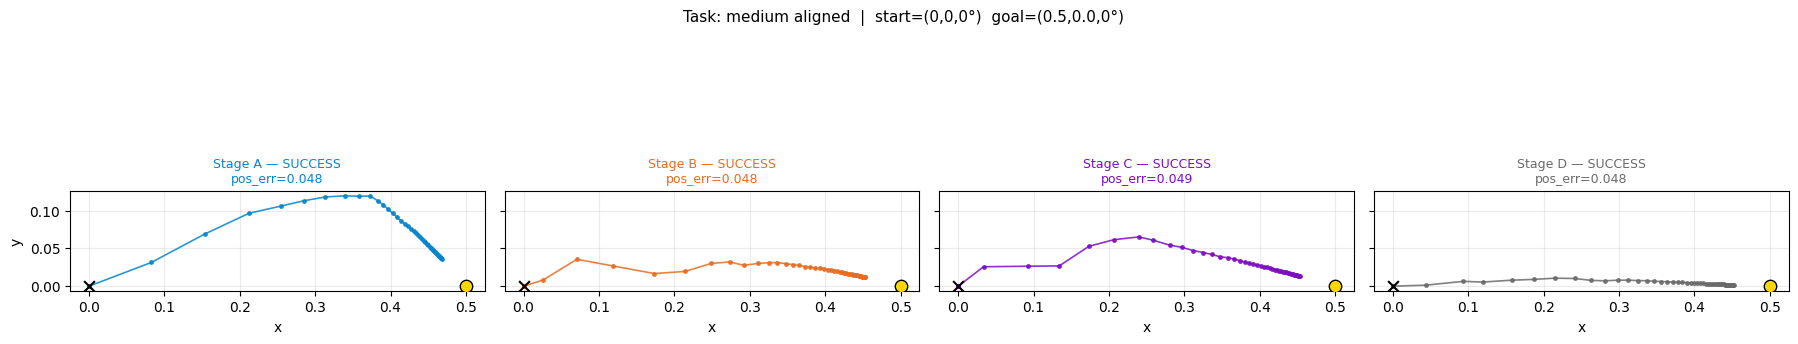

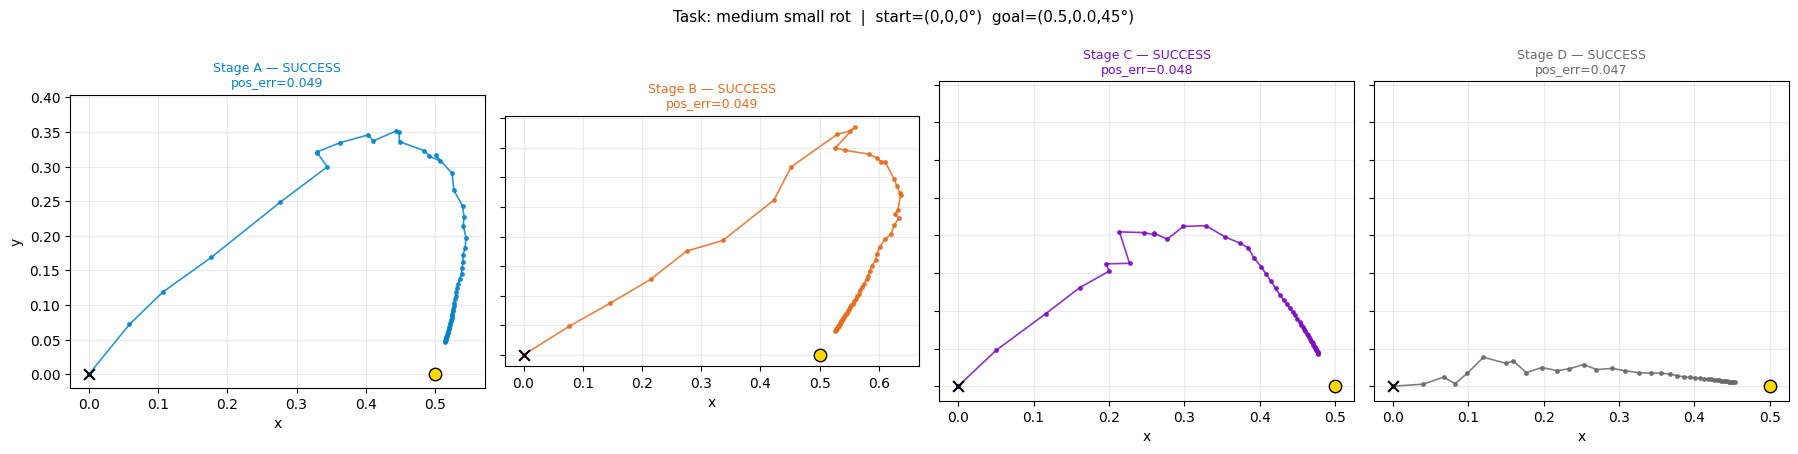

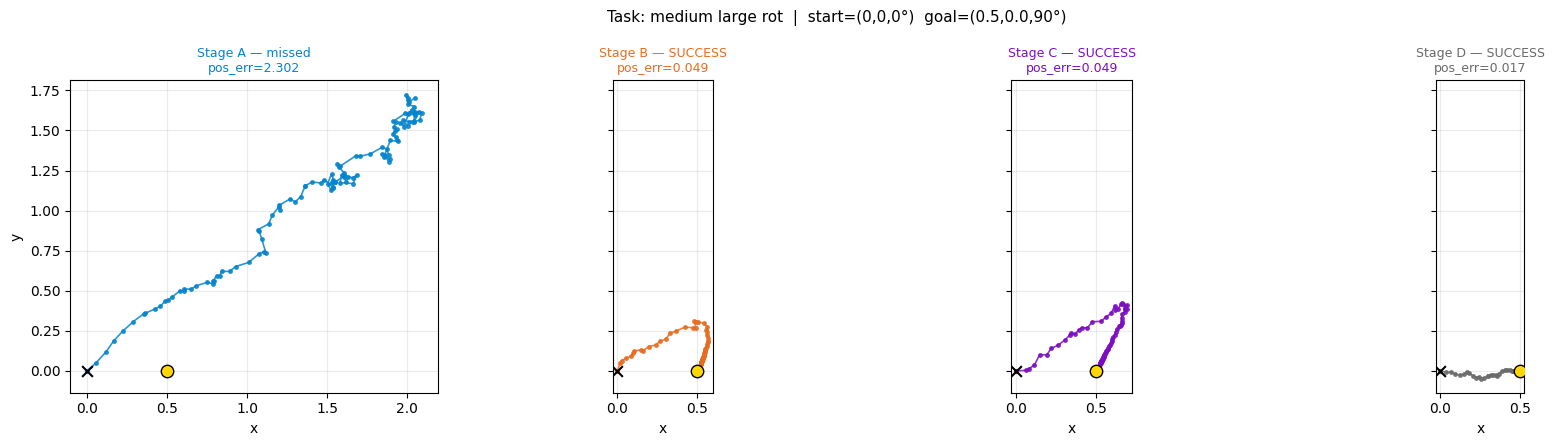

In [10]:
def plot_trajectories_for_task(results, task_name, stages, task_configs):
    """Plot best trial (lowest pos+angle error) for each stage on the given task."""
    task = task_configs[task_name]
    task_results = {stage: [] for stage in stages}
    for result in results:
        if result.task_name == task_name and result.params_name in task_results:
            task_results[result.params_name].append(result)

    fig, axes = plt.subplots(1, len(stages), figsize=(4.5 * len(stages), 4.5), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, stage in zip(axes, stages):
        colour = STAGE_COLOURS[stage]
        trials = task_results[stage]
        if not trials:
            ax.set_title(f"Stage {stage} — no data")
            continue
        best = min(trials, key=lambda r: r.final_pos_error + r.final_angle_error)
        traj = best.trajectory
        ax.plot([s.obj_x for s in traj], [s.obj_y for s in traj],
                "o-", markersize=2.5, lw=1.2, color=colour, alpha=0.85)
        ax.scatter([task.start_x], [task.start_y], c="black", marker="x", s=60, zorder=5)
        ax.scatter([task.goal_x], [task.goal_y], c="gold", edgecolors="black", s=80, zorder=5)
        status = "SUCCESS" if best.success else "missed"
        ax.set_title(f"Stage {stage} — {status}\npos_err={best.final_pos_error:.3f}",
                     fontsize=9, color=colour)
        ax.set_xlabel("x")
        ax.grid(alpha=0.25)
        ax.set_aspect("equal", adjustable="box")

    axes[0].set_ylabel("y")
    fig.suptitle(f"Task: {task_name.replace('_', ' ')}  |  start=(0,0,0°)  goal=({task.goal_x},{task.goal_y},{np.degrees(task.goal_angle):.0f}°)",
                 fontsize=11)
    plt.tight_layout()
    plt.show()

# Show trajectories for the medium-rotated conditions
for task_name in ["medium_aligned", "medium_small_rot", "medium_large_rot"]:
    plot_trajectories_for_task(results, task_name, list(DEVELOPMENTAL_STAGES), TASKS)